# DSE Risk Scoring & Anomaly Detection
**Brand: IM3 & 3ID | Data: April 2026**

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.metrics import roc_auc_score


import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', None)

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
print('Libraries loaded.')

Libraries loaded.


---
## 1. **Load Data**

In [70]:
FILE_PATH = 'Performance SLA DSE 202604.xlsm' 

df_im3    = pd.read_excel(FILE_PATH, sheet_name='DSE_IM3',    header=2)
df_3id    = pd.read_excel(FILE_PATH, sheet_name='DSE_3ID',    header=2)
df_im3_ec = pd.read_excel(FILE_PATH, sheet_name='DSE_IM3_EC', header=3)
df_3id_ec = pd.read_excel(FILE_PATH, sheet_name='DSE_3ID_EC', header=3)

df_im3['BRAND_SRC']    = 'IM3'
df_3id['BRAND_SRC']    = '3ID'
df_im3_ec['BRAND_SRC'] = 'IM3'
df_3id_ec['BRAND_SRC'] = '3ID'

print(f'IM3 main : {df_im3.shape}  |  3ID main : {df_3id.shape}')
print(f'IM3 EC   : {df_im3_ec.shape}  |  3ID EC   : {df_3id_ec.shape}')

IM3 main : (1056, 55)  |  3ID main : (1073, 55)
IM3 EC   : (1056, 119)  |  3ID EC   : (1073, 119)


---
## 2. **PROCESSING** — DSE_IM3 & DSE_3ID

Kolom yang dipetakan:
- **SP Sellin** : TARGET, ACTUAL, %ACH, MTD TARGET, %ACH MTD
- **OSA**       : TARGET.1, ACTUAL.1, %ACH.1, MTD TARGET.1, %ACH MTD.1
- **RGUGA FWA** : TARGET.2, ACTUAL.2, %ACH.2, MTD TARGET.2, %ACH MTD.2
- **Score**     : Score Sellin / Scorre Sellin, Score EC / SCORE EC
- **Champions** : SP SELLIN, OSA, FWA/RGUGA FWA, Total Score, MTD versions
- **Coverage**  : OUTLET MAPPING, FLAG TARGET, TARGET SELLIN
- **Flag**      : flag densus / Flag densus

### KPI SP (Sell-in Performance)
| Fitur | Deskripsi |
|------|-----------|
| SP_TARGET | Target penjualan SP. |
| SP_ACTUAL | Realisasi penjualan SP. |
| SP_ACH | Persentase pencapaian SP terhadap target. |
| SP_UNIT_PRICE | Harga satuan produk SP. |
| SP_INCENTIVE | Insentif dari KPI SP. |

### KPI OSA (Availability)
| Fitur | Deskripsi |
|------|-----------|
| OSA_TARGET | Target availability. |
| OSA_ACTUAL | Realisasi availability. |
| OSA_ACH | Persentase pencapaian OSA. |
| OSA_UNIT_PRICE | Harga satuan OSA KPI. |
| OSA_INCENTIVE | Insentif dari KPI OSA. |

### KPI FWA
| Fitur | Deskripsi |
|------|-----------|
| FWA_TARGET | Target FWA. |
| FWA_ACTUAL | Realisasi FWA. |
| FWA_ACH | Persentase pencapaian FWA. |
| FWA_UNIT_PRICE | Nilai per unit FWA. |
| FWA_INCENTIVE | Insentif dari KPI FWA. |

### Coverage & Targeting
| Fitur | Deskripsi |
|------|-----------|
| OUTLET_MAPPING | Jumlah/outlet mapping yang terdaftar. |
| FLAG_TARGET | Penanda apakah outlet termasuk target. |
| TARGET_SELLIN | Target sell-in total. |
| SP_SELLIN_ACTUAL | Realisasi sell-in SP. |

### Score & Index
| Fitur | Deskripsi |
|------|-----------|
| SCORE_SELLIN | Skor performa sell-in. |
| SCORE_EC | Skor efficiency (EC). |
| CHAMP_TOTAL | Total composite score. |

### KPI Aggregation
| Fitur | Deskripsi |
|------|-----------|
| KPI_AVG_ACH | Rata-rata pencapaian SP, OSA, FWA. |
| KPI_STD | Standar deviasi KPI (konsistensi performa). |

### Compliance & Incentive
| Fitur | Deskripsi |
|------|-----------|
| COMPLIANCE_INDEX | Indeks kepatuhan terhadap aturan/target. |
| TOTAL_INCENTIVE | Total insentif (SP + OSA + FWA). |
| INCENTIVE_FINAL_AFTER_COMPLIANCE | Insentif final setelah compliance. |

### Coverage Efficiency
| Fitur | Deskripsi |
|------|-----------|
| COVERAGE_RATE | Rasio SP actual terhadap target sell-in. |

In [71]:
print(df_im3.columns.tolist())

['BRAND', 'DSE CATEGORY', 'DSE IDE', 'flag densus', 'PARTNER ID', 'PARTNER NAME', 'PT', 'MICRO CLUSTER', 'BRANCH', 'AREA', 'REGION', 'CIRCLE', 'TARGET', 'ACTUAL', '%ACH', 'MTD TARGET', '%ACH MTD', 'UNIT PRICE', 'INCENTIVE', 'TARGET.1', 'ACTUAL.1', '%ACH.1', 'MTD TARGET.1', '%ACH MTD.1', 'UNIT PRICE.1', 'INCENTIVE.1', 'TARGET.2', 'ACTUAL.2', '%ACH.2', 'MTD TARGET.2', '%ACH MTD.2', 'UNIT PRICE.2', 'INCENTIVE.2', 'OUTLET MAPPING', 'FLAG TARGET', 'TARGET SELLIN 3PCS', 'SP SELLIN ', 'Score Sellin', 'Score EC', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'SP SELLIN', 'OSA', 'FWA', 'Total Score', 'SP SELLIN MTD', 'OSA MTD', 'RGUGA FWA MTD', 'Total Score MTD', 'Unnamed: 53', 'BRAND_SRC']


In [72]:
print(df_3id.columns.tolist())

['BRAND', 'DSE CATEGORY', 'DSE ID', 'Flag densus', 'PARTNER ID', 'PARTNER NAME', 'PT', 'MICRO CLUSTER', 'BRANCH', 'AREA', 'REGION', 'CIRCLE', 'TARGET', 'ACTUAL', '%ACH', 'MTD TARGET', '%ACH MTD', 'UNIT PRICE', 'INCENTIVE', 'TARGET.1', 'ACTUAL.1', '%ACH.1', 'MTD TARGET.1', '%ACH MTD.1', 'UNIT PRICE.1', 'INCENTIVE.1', 'TARGET.2', 'ACTUAL.2', '%ACH.2', 'MTD TARGET.2', '%ACH MTD.2', 'UNIT PRICE.2', 'INCENTIVE.2', 'OUTLET MAPPING', 'FLAG TARGET', 'TARGET SELLIN', 'SP SELLIN', 'Scorre Sellin', 'SCORE EC', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'SP SELLIN.1', 'OSA', 'RGUGA FWA', 'Total Score', 'SP SELLIN MTD', 'OSA MTD', 'RGUGA FWA MTD', 'Total Score MTD', 'Unnamed: 53', 'BRAND_SRC']


cek isi column unnamed

In [73]:
df_im3[['Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42']].head()

,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42
0,1.00,1.00,NaN,"600,000.00"
1,1.00,1.00,NaN,"815,127.70"
2,1.00,1.00,NaN,"600,000.00"
3,0.93,0.97,NaN,"700,191.50"
4,1.00,1.00,NaN,"600,000.00"


In [74]:
df_3id[['Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42']].head()

,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42
0,1.00,1.00,NaN,"387,435.00"
1,1.00,1.00,NaN,"324,370.00"
2,0.76,0.00,NaN,"666,430.50"
3,0.72,0.00,NaN,"300,089.70"
4,0.63,0.00,NaN,"671,224.00"


In [75]:
def parse_num(series):
    """Bersihkan kolom numerik: hapus %, spasi, tanda strip."""
    return (
        series.astype(str)
        .str.replace('%', '', regex=False)
        .str.replace(',', '.', regex=False)
        .str.replace(' ', '', regex=False)
        .str.replace('-', '0', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )

def to_pct_numeric(series):
    s = pd.to_numeric(series, errors='coerce')
    return np.where(s.between(0, 1.5), s * 100, s)

def extract_main_features(df, brand):
    cols = df.columns.tolist()

    # Rename kolom compliance & incentive hasil merge header Excel
    rename_map = {}
    if 'Unnamed: 39' in cols:
        rename_map['Unnamed: 39'] = 'TOTAL_COMPLIANCE'
    if 'Unnamed: 40' in cols:
        rename_map['Unnamed: 40'] = 'COMPLIANCE_INDEX'
    if 'Unnamed: 41' in cols:
        rename_map['Unnamed: 41'] = 'BEFORE_COMPLIANCE'
    if 'Unnamed: 42' in cols:
        rename_map['Unnamed: 42'] = 'FINAL_AFTER_COMPLIANCE'

    df = df.rename(columns=rename_map)

    # update cols setelah rename
    cols = df.columns.tolist()

    # Normalisasi nama kolom ID & flag
    id_col   = 'DSE ID'    if 'DSE ID'    in cols else 'DSE IDE'
    flag_col = 'flag densus' if 'flag densus' in cols else 'Flag densus'

    # Score Sellin (IM3: 'Score Sellin', 3ID: 'Scorre Sellin')
    score_sellin_col = 'Score Sellin' if 'Score Sellin' in cols else 'Scorre Sellin'
    # Score EC (IM3: 'Score EC', 3ID: 'SCORE EC')
    score_ec_col = 'Score EC' if 'Score EC' in cols else 'SCORE EC'
    # Champions FWA (IM3: 'FWA', 3ID: 'RGUGA FWA')
    fwa_col = 'FWA' if 'FWA' in cols else 'RGUGA FWA'
    # Target sellin (IM3: 'TARGET SELLIN 3PCS', 3ID: 'TARGET SELLIN')
    target_sellin_col = 'TARGET SELLIN 3PCS' if 'TARGET SELLIN 3PCS' in cols else 'TARGET SELLIN'
    # SP SELLIN champions (IM3: 'SP SELLIN ', 3ID: 'SP SELLIN.1')
    sp_champ_col = 'SP SELLIN ' if 'SP SELLIN ' in cols else ('SP SELLIN.1' if 'SP SELLIN.1' in cols else 'SP SELLIN')

    out = pd.DataFrame()
    out['DSE_ID']        = df[id_col].astype(str).str.strip()
    out['BRAND_SRC']     = brand
    out['FLAG_DENSUS']   = parse_num(df[flag_col])
    out['PARTNER_NAME']  = df.get('PARTNER NAME', pd.Series([''] * len(df))).astype(str)
    out['MICRO_CLUSTER'] = df.get('MICRO CLUSTER', pd.Series([''] * len(df))).astype(str)
    out['BRANCH']        = df.get('BRANCH', pd.Series([''] * len(df))).astype(str)
    out['AREA']          = df.get('AREA', pd.Series([''] * len(df))).astype(str)
    out['REGION']        = df.get('REGION', pd.Series([''] * len(df))).astype(str)

    # ── SP Sellin KPI
    out['SP_TARGET']      = parse_num(df['TARGET'])
    out['SP_ACTUAL']      = parse_num(df['ACTUAL'])
    out['SP_ACH']         = to_pct_numeric(df['%ACH'])
    out['SP_UNIT_PRICE']  = parse_num(df['UNIT PRICE'])
    out['SP_INCENTIVE']   = parse_num(df['INCENTIVE'])

    # ── OSA KPI
    out['OSA_TARGET']     = parse_num(df['TARGET.1'])
    out['OSA_ACTUAL']     = parse_num(df['ACTUAL.1'])
    out['OSA_ACH']        = to_pct_numeric(df['%ACH.1'])
    out['OSA_UNIT_PRICE'] = parse_num(df['UNIT PRICE.1'])
    out['OSA_INCENTIVE']  = parse_num(df['INCENTIVE.1'])

    # ── RGUGA FWA KPI
    out['FWA_TARGET']     = parse_num(df['TARGET.2'])
    out['FWA_ACTUAL']     = parse_num(df['ACTUAL.2'])
    out['FWA_ACH']        = to_pct_numeric(df['%ACH.2'])
    out['FWA_UNIT_PRICE'] = parse_num(df['UNIT PRICE.2'])
    out['FWA_INCENTIVE']  = parse_num(df['INCENTIVE.2'])

    # ── Coverage outlet
    out['OUTLET_MAPPING']  = parse_num(df.get('OUTLET MAPPING', pd.Series([0]*len(df))))
    out['FLAG_TARGET']     = parse_num(df.get('FLAG TARGET', pd.Series([0]*len(df))))
    out['TARGET_SELLIN']   = parse_num(df.get(target_sellin_col, pd.Series([0]*len(df))))
    out['SP_SELLIN_ACTUAL']= parse_num(df.get('SP SELLIN', pd.Series([0]*len(df))))

    # ── Score per dimensi
    out['SCORE_SELLIN']    = parse_num(df.get(score_sellin_col, pd.Series([0]*len(df))))
    out['SCORE_EC']        = parse_num(df.get(score_ec_col, pd.Series([0]*len(df))))

    # ── Champions score (SP SELLIN, OSA, FWA, Total)
    # out['CHAMP_SP']        = parse_num(df.get(sp_champ_col, pd.Series([0]*len(df))))
    # out['CHAMP_OSA']       = parse_num(df.get('OSA', pd.Series([0]*len(df))))
    # out['CHAMP_FWA']       = parse_num(df.get(fwa_col, pd.Series([0]*len(df))))
    out['CHAMP_TOTAL']     = parse_num(df.get('Total Score', pd.Series([0]*len(df))))

    # Rata-rata achievement 3 KPI
    out['KPI_AVG_ACH']     = out[['SP_ACH','OSA_ACH','FWA_ACH']].mean(axis=1)

    # Konsistensi KPI (std rendah = seimbang antar KPI)
    out['KPI_STD']         = out[['SP_ACH','OSA_ACH','FWA_ACH']].std(axis=1)

    # Compliance
    out['COMPLIANCE_INDEX'] = parse_num(df.get('COMPLIANCE_INDEX', pd.Series([0]*len(df))))

    # Total insentif
    out['TOTAL_INCENTIVE'] = out['SP_INCENTIVE'] + out['OSA_INCENTIVE'] + out['FWA_INCENTIVE']
    out['INCENTIVE_FINAL_AFTER_COMPLIANCE'] =  parse_num(df.get('FINAL_AFTER_COMPLIANCE', pd.Series([0]*len(df))))

    # Coverage rate (SP SELLIN actual / TARGET SELLIN)
    out['COVERAGE_RATE'] = out['SP_SELLIN_ACTUAL'] / (out['TARGET_SELLIN'].replace(0, np.nan))

    return out.dropna(subset=['DSE_ID'])


feat_im3_main = extract_main_features(df_im3, 'IM3')
feat_3id_main = extract_main_features(df_3id, '3ID')
df_main_feat  = pd.concat([feat_im3_main, feat_3id_main], ignore_index=True)

print(f'Main features: {df_main_feat.shape[0]} DSE x {df_main_feat.shape[1]} kolom')
print(df_main_feat.columns.tolist())

Main features: 2129 DSE x 36 kolom
['DSE_ID', 'BRAND_SRC', 'FLAG_DENSUS', 'PARTNER_NAME', 'MICRO_CLUSTER', 'BRANCH', 'AREA', 'REGION', 'SP_TARGET', 'SP_ACTUAL', 'SP_ACH', 'SP_UNIT_PRICE', 'SP_INCENTIVE', 'OSA_TARGET', 'OSA_ACTUAL', 'OSA_ACH', 'OSA_UNIT_PRICE', 'OSA_INCENTIVE', 'FWA_TARGET', 'FWA_ACTUAL', 'FWA_ACH', 'FWA_UNIT_PRICE', 'FWA_INCENTIVE', 'OUTLET_MAPPING', 'FLAG_TARGET', 'TARGET_SELLIN', 'SP_SELLIN_ACTUAL', 'SCORE_SELLIN', 'SCORE_EC', 'CHAMP_TOTAL', 'KPI_AVG_ACH', 'KPI_STD', 'COMPLIANCE_INDEX', 'TOTAL_INCENTIVE', 'INCENTIVE_FINAL_AFTER_COMPLIANCE', 'COVERAGE_RATE']


In [76]:
df_main_feat

,DSE_ID,BRAND_SRC,FLAG_DENSUS,PARTNER_NAME,MICRO_CLUSTER,BRANCH,AREA,REGION,SP_TARGET,SP_ACTUAL,SP_ACH,SP_UNIT_PRICE,SP_INCENTIVE,OSA_TARGET,OSA_ACTUAL,OSA_ACH,OSA_UNIT_PRICE,OSA_INCENTIVE,FWA_TARGET,FWA_ACTUAL,FWA_ACH,FWA_UNIT_PRICE,FWA_INCENTIVE,OUTLET_MAPPING,FLAG_TARGET,TARGET_SELLIN,SP_SELLIN_ACTUAL,SCORE_SELLIN,SCORE_EC,CHAMP_TOTAL,KPI_AVG_ACH,KPI_STD,COMPLIANCE_INDEX,TOTAL_INCENTIVE,INCENTIVE_FINAL_AFTER_COMPLIANCE,COVERAGE_RATE
0,DSEBANYU21,IM3,0,"GAS POL INDONESIA, CV",MC-BANYUWANGI,JEMBER,EASTERN EAST JAVA,EAST JAVA,621,847,120.00,1500,400000,"142,876,638.70",81218000,56.84,0.00,0.00,1,2,120.00,200000,200000,62,0.50,31,1.20,1.00,1.00,1.01,98.95,36.46,1.00,"600,000.00","600,000.00",0.04
1,DSEBANYU23,IM3,0,"GAS POL INDONESIA, CV",MC-BANYUWANGI,JEMBER,EASTERN EAST JAVA,EAST JAVA,462,615,120.00,1500,400000,"87,045,677.84",107563850,120.00,0.00,"215,127.70",1,2,120.00,200000,200000,56,0.50,28,1.20,1.00,1.00,1.20,120.00,0.00,1.00,"815,127.70","815,127.70",0.04
2,DSEBANYU25,IM3,0,"GAS POL INDONESIA, CV",MC-BANYUWANGI,JEMBER,EASTERN EAST JAVA,EAST JAVA,460,660,120.00,1500,400000,"92,473,791.39",81045000,87.64,0.00,0.00,1,2,120.00,200000,200000,64,0.50,32,1.20,1.00,1.00,1.10,109.21,18.68,1.00,"600,000.00","600,000.00",0.04
3,DSEBANYU27,IM3,0,"GAS POL INDONESIA, CV",MC-BANYUWANGI,JEMBER,EASTERN EAST JAVA,EAST JAVA,491,779,120.00,1500,400000,"87,280,951.37",100095750,114.68,0.00,"200,191.50",1,1,100.00,100000,100000,65,0.50,33,1.20,1.00,0.86,1.12,111.56,10.36,0.97,"700,191.50","700,191.50",0.04
4,DSEBANYU28,IM3,0,"GAS POL INDONESIA, CV",MC-BANYUWANGI,JEMBER,EASTERN EAST JAVA,EAST JAVA,461,731,120.00,1500,400000,"122,128,830.00",77154900,63.18,0.00,0.00,1,2,120.00,200000,200000,34,0.50,17,1.20,1.00,1.00,1.03,101.06,32.81,1.00,"600,000.00","600,000.00",0.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2124,1-135260875338,3ID,0,CV PURNAMA JAYA ABADI,CS KENDAL,SEMARANG,NORTH CENTRAL JAVA,CENTRAL JAVA,300,351,117.00,1500,400000,"289,000,000.00",307158000,106.28,0.00,"400,000.00",1,2,120.00,200000,200000,72,0.50,36,58.00,1.00,1.00,1.15,114.43,7.21,1.00,"1,000,000.00","1,000,000.00",1.61
2125,1-135260875246,3ID,0,CV PURNAMA JAYA ABADI,CS KENDAL,SEMARANG,NORTH CENTRAL JAVA,CENTRAL JAVA,250,323,120.00,1500,400000,"178,000,000.00",190341000,106.93,0.00,"380,682.00",1,2,120.00,200000,200000,56,0.50,28,37.00,1.00,1.00,1.16,115.64,7.54,1.00,"980,682.00","980,682.00",1.32
2126,1-28825219097,3ID,0,KIOSK_CV CHAYOO ABADI_BOJA_KENDAL,CS KENDAL,SEMARANG,NORTH CENTRAL JAVA,CENTRAL JAVA,292,274,93.84,1000,274000,"91,108,662.92",73426750,80.59,0.00,0.00,1,2,120.00,200000,200000,44,0.50,22,37.00,1.00,1.00,0.98,98.14,20.05,1.00,"474,000.00","474,000.00",1.68
2127,1-135260875312,3ID,0,CV PURNAMA JAYA ABADI,CS KENDAL,SEMARANG,NORTH CENTRAL JAVA,CENTRAL JAVA,250,305,120.00,1500,400000,"275,000,000.00",298277500,108.46,0.00,"400,000.00",1,2,120.00,200000,200000,53,0.50,27,44.00,1.00,1.00,1.17,116.15,6.66,1.00,"1,000,000.00","1,000,000.00",1.63


---
## 3. **Preprocessing & Feature Engineering** — Sheet EC (Data Harian)

### Identitas & Konteks
| Fitur | Deskripsi |
|------|-----------|
| OUTLET | Jumlah/outlet mapping atau PJP outlet (tergantung brand). |
| THRESHOLD_EC | Batas minimum EC (target internal compliance EC). |

### Aktivitas & Hari Kerja
| Fitur | Deskripsi |
|------|-----------|
| N_HARI_KERJA | Jumlah hari aktif (hari dengan visit atau sell-in). |

### Visit (Kunjungan)
| Fitur | Deskripsi |
|------|-----------|
| AVG_VISIT | Rata-rata jumlah visit per hari kerja. |
| VISIT_CV | Koefisien variasi visit (konsistensi kunjungan; makin kecil = makin stabil). |

### Sell-in (Performa Penjualan)
| Fitur | Deskripsi |
|------|-----------|
| AVG_SELLIN | Rata-rata sell-in per hari kerja. |
| SELLIN_CV | Variasi sell-in (konsistensi penjualan harian). |
| SELLIN_PER_VISIT | Efektivitas kunjungan menghsilkan sell in (sell-in per visit). |

### EC (Compliance Rate)
| Fitur | Deskripsi |
|------|-----------|
| EC_RATE | Persentase hari dengan EC = 100 (indikator compliance EC). |
| EC_TREND_WEEKLY | Tren EC antar minggu (positif = membaik, negatif = memburuk). |

###  Konsentrasi Waktu Aktivitas
| Fitur | Deskripsi |
|------|-----------|
| EOM_CONCENTRATION | Proporsi visit di 5 hari terakhir bulan (End of Month behavior). |
| SOM_CONCENTRATION | Proporsi visit di 5 hari pertama bulan (Start of Month behavior). |
| MID_CONCENTRATION | Proporsi visit di hari tengah bulan (hari 8–22). |

###  Kepatuhan Threshold
| Fitur | Deskripsi |
|------|-----------|
| BELOW_THRESHOLD_RATE | Proporsi hari di mana visit/sell-in di bawah threshold EC. |


###  Summary Aktivitas
| Fitur | Deskripsi |
|------|-----------|
| TOTAL_VISIT_SUMMARY | Total visit dalam periode observasi. |
| TOTAL_SELLIN_SUMMARY | Total sell-in dalam periode observasi. |
| AVG_EC_SUMMARY | Rata-rata EC dari ringkasan (fallback jika data harian tidak lengkap). |

In [77]:
def extract_ec_features(df, brand):
    """
    Ekstrak fitur dari pola harian Visit / Sellin>50k / EC.
    Handle perbedaan IM3 vs 3ID:
    - IM3: threshold col = 'THEREHOLD EC', outlet = 'OUTLET MAPPING', ada 1 kolom ' ' (hari libur day-5)
    - 3ID: threshold col = 'THERSHOLD EC', outlet = 'OUTLET PJP'
    """
    cols = df.columns.tolist()

    id_col        = 'DSE ID'
    thresh_col    = 'THEREHOLD EC' if 'THEREHOLD EC' in cols else 'THERSHOLD EC' if 'THERSHOLD EC' in cols else 'THRESHOLD EC'
    outlet_col    = 'OUTLET MAPPING' if 'OUTLET MAPPING' in cols else 'OUTLET PJP'

    df = df.dropna(subset=[id_col]).copy() # Pastikan hanya DSE yang memiliki ID yang diproses
    df = df.rename(columns={id_col: 'DSE_ID'})

    # Identifikasi kelompok Visit/Sellin/EC
    # Pola: Visit, Sellin>50k, EC berulang untuk 30 hari
    visit_cols  = [c for c in cols if str(c).startswith('Visit')]
    sellin_cols = [c for c in cols if str(c).startswith('Sellin')]
    ec_cols     = [c for c in cols if str(c).startswith('EC') and c not in ['EC.x','EC.y']]

    n_days = min(len(visit_cols), len(sellin_cols), len(ec_cols))
    print(f'  [{brand}] Hari terdeteksi: {n_days}')

    rows = []
    for _, row in df.iterrows():
        dse_id    = str(row['DSE_ID']).strip()
        threshold = pd.to_numeric(str(row.get(thresh_col, 0)).replace(' ',''), errors='coerce') or 0
        outlet    = pd.to_numeric(str(row.get(outlet_col, 0)).replace(' ',''), errors='coerce') or 0

        visits, sellins, ecs = [], [], []
        for i in range(n_days):
            v  = pd.to_numeric(str(row.get(visit_cols[i],  0)).replace(' ','').replace('-','0'), errors='coerce') or 0
            s  = pd.to_numeric(str(row.get(sellin_cols[i], 0)).replace(' ','').replace('-','0'), errors='coerce') or 0
            e  = str(row.get(ec_cols[i], '0%'))
            en = pd.to_numeric(e.replace('%','').replace(' ',''), errors='coerce') or 0
            if en <= 1.5: en *= 100
            visits.append(v); sellins.append(s); ecs.append(en)

        # Hari libur = visit=0 & sellin=0
        hari_libur = [v == 0 and s == 0 for v, s in zip(visits, sellins)]
        kerja_idx  = [i for i, h in enumerate(hari_libur) if not h]
        n_kerja    = len(kerja_idx) or 1

        vk = [visits[i]  for i in kerja_idx]
        sk = [sellins[i] for i in kerja_idx]
        ek = [ecs[i]     for i in kerja_idx]

        # ── Fitur agregat
        avg_visit   = np.mean(vk) if vk else 0
        avg_sellin  = np.mean(sk) if sk else 0
        ec_rate     = np.mean([1 if e==100 else 0 for e in ek]) if ek else 0
        visit_std   = np.std(vk) if len(vk)>1 else 0 # Untuk melihat konsistensi kunjungan harian, std kecil = konsisten
        # Coefficient of Variation (CV) untuk visit & sellin
        visit_cv = visit_std / avg_visit if avg_visit > 0 else 0 # Untuk melihat konsistensi kunjungan harian relatif terhadap rata-rata, cv kecil = konsisten
        sellin_cv = np.std(sk) / avg_sellin if avg_sellin > 0 else 0 # Untuk melihat konsistensi penjualan relatif terhadap rata-rata, cv kecil = konsisten

        # Produktivitas: outlet yang di-visit dengan sellin per hari
        sellin_per_visit = avg_sellin / avg_visit if avg_visit > 0 else 0

        # ── Konsentrasi waktu kunjungan
        # EOM: % visit di 5 hari terakhir
        last5 = kerja_idx[-5:] if len(kerja_idx)>=5 else kerja_idx
        eom_visit = sum(visits[i] for i in last5)
        total_visit = sum(vk) or 1
        eom_concentration = eom_visit / total_visit

        # SOM: % visit di 5 hari pertama
        first5 = kerja_idx[:5] if len(kerja_idx)>=5 else kerja_idx
        som_visit = sum(visits[i] for i in first5)
        som_concentration = som_visit / total_visit

        # Rasio kunjungan tengah bulan (hari ke 8-22)
        mid_idx = [i for i in kerja_idx if 7 <= i <= 21]
        mid_visit = sum(visits[i] for i in mid_idx)
        mid_concentration = mid_visit / total_visit

        # ── Threshold compliance
        below_threshold_rate = np.mean([1 if v < threshold else 0 for v in vk]) if vk else 0

        # ── Tren EC mingguan (apakah membaik atau memburuk)
        # Bagi 4 minggu, hitung rata-rata EC per minggu
        week_ec = []
        for w in range(4):
            w_idx = [i for i in kerja_idx if w*7 <= i < (w+1)*7]
            if w_idx:
                week_ec.append(np.mean([ecs[i] for i in w_idx]))
        ec_trend = 0
        if len(week_ec) >= 2:
            # Slope sederhana: positif = membaik, negatif = memburuk
            ec_trend = (week_ec[-1] - week_ec[0]) / (len(week_ec) - 1)

        # ── Aggregat summary dari kolom ringkasan
        jumlah_visit = sum(visits)
        total_sellin = sum(sellins)
        avg_ec_summary = pd.to_numeric(str(row.get('ec', 0)).replace('%','').replace(' ',''), errors='coerce') or ec_rate
        if avg_ec_summary <= 1.5: avg_ec_summary *= 100

        rows.append({
            'DSE_ID'               : dse_id,
            'BRAND_SRC'            : brand,
            'OUTLET    '           : outlet,
            'THRESHOLD_EC'         : threshold,
            'N_HARI_KERJA'         : n_kerja,
            # Visit
            'AVG_VISIT'            : round(avg_visit, 2),
            'VISIT_CV'             : round(visit_cv, 3),
            # Sellin
            'AVG_SELLIN'           : round(avg_sellin, 2),
            'SELLIN_CV'            : round(sellin_cv, 3),
            'SELLIN_PER_VISIT'     : round(sellin_per_visit, 2),
            # EC
            'EC_RATE'              : round(ec_rate, 3),
            'EC_TREND_WEEKLY'      : round(ec_trend, 2),
            # Konsentrasi waktu
            'EOM_CONCENTRATION'    : round(eom_concentration, 3),
            'SOM_CONCENTRATION'    : round(som_concentration, 3),
            'MID_CONCENTRATION'    : round(mid_concentration, 3),
            # Threshold
            'BELOW_THRESHOLD_RATE' : round(below_threshold_rate, 3),
            # Summary
            'TOTAL_SELLIN_SUMMARY' : total_sellin,
            'TOTAL_VISIT_SUMMARY'  : jumlah_visit,
            'AVG_EC_SUMMARY'       : round(avg_ec_summary, 1),
        })

    return pd.DataFrame(rows)


print('Ekstrak fitur EC IM3...')
feat_im3_ec = extract_ec_features(df_im3_ec, 'IM3')
print('Ekstrak fitur EC 3ID...')
feat_3id_ec = extract_ec_features(df_3id_ec, '3ID')
df_ec_feat = pd.concat([feat_im3_ec, feat_3id_ec], ignore_index=True)

print(f'\nEC features: {df_ec_feat.shape[0]} DSE x {df_ec_feat.shape[1]} kolom')

Ekstrak fitur EC IM3...
  [IM3] Hari terdeteksi: 30
Ekstrak fitur EC 3ID...
  [3ID] Hari terdeteksi: 30

EC features: 2129 DSE x 19 kolom


In [78]:
df_ec_feat.head(30)

,DSE_ID,BRAND_SRC,OUTLET,THRESHOLD_EC,N_HARI_KERJA,AVG_VISIT,VISIT_CV,AVG_SELLIN,SELLIN_CV,SELLIN_PER_VISIT,EC_RATE,EC_TREND_WEEKLY,EOM_CONCENTRATION,SOM_CONCENTRATION,MID_CONCENTRATION,BELOW_THRESHOLD_RATE,TOTAL_SELLIN_SUMMARY,TOTAL_VISIT_SUMMARY,AVG_EC_SUMMARY
0,DSEBANYU21,IM3,62,8,21,19.14,0.40,18.62,0.41,0.97,0.71,18.33,0.27,0.12,0.74,0.14,391,402,37.00
1,DSEBANYU23,IM3,56,8,21,17.24,0.40,17.10,0.40,0.99,0.71,26.67,0.28,0.15,0.69,0.14,359,362,46.00
2,DSEBANYU25,IM3,64,8,21,20.48,0.35,18.29,0.39,0.89,0.91,13.33,0.24,0.16,0.70,0.10,384,430,41.00
3,DSEBANYU27,IM3,65,8,21,14.90,0.36,14.62,0.36,0.98,0.43,3.33,0.24,0.20,0.66,0.10,307,313,46.00
4,DSEBANYU28,IM3,34,8,18,18.11,0.20,14.67,0.45,0.81,0.72,33.33,0.26,0.32,0.74,0.00,264,326,6.00
5,DSEBANYU29,IM3,34,8,18,14.22,0.42,14.06,0.42,0.99,0.72,33.33,0.33,0.26,0.74,0.22,253,256,2.00
6,DSE42311114,IM3,33,5,24,15.83,0.39,6.00,0.60,0.38,0.54,-12.38,0.18,0.15,0.62,0.12,144,380,26.00
7,DSEBWS01,IM3,56,5,21,13.81,0.32,13.19,0.35,0.96,0.95,6.67,0.22,0.20,0.67,0.00,277,290,44.00
8,DSEBWS03,IM3,60,5,25,8.88,0.75,8.56,0.77,0.96,0.36,-12.38,0.20,0.15,0.63,0.20,214,222,42.00
9,DSEBWS06,IM3,57,5,21,15.48,0.40,11.43,0.62,0.74,0.95,-8.33,0.23,0.20,0.69,0.00,240,325,43.00


---
## 4. **Merge** — Gabungkan Semua Fitur

In [79]:
# Merge main + EC features
df_feat = df_ec_feat.merge(
    df_main_feat.drop(columns=['BRAND_SRC'], errors='ignore'),
    on='DSE_ID', how='left'
)

# Isi missing dengan median
num_cols = df_feat.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    df_feat[col] = df_feat[col].fillna(df_feat[col].median())

print(f'Final feature table: {df_feat.shape[0]} DSE x {df_feat.shape[1]} kolom')

# Daftar fitur numerik untuk model
MODEL_FEATURES = [
    # EC harian
    'EC_RATE', 'EC_TREND_WEEKLY',
    # Visit pattern
    'AVG_VISIT', 'VISIT_CV', 'ZERO_VISIT_RATE', 'MAX_GAP_HARI',
    # Sellin pattern
    'AVG_SELLIN', 'SELLIN_CV', 'SELLIN_PER_VISIT',
    # Konsentrasi waktu
    'EOM_CONCENTRATION', 'SOM_CONCENTRATION', 'MID_CONCENTRATION',
    'BELOW_THRESHOLD_RATE',
    # KPI achievement
    'SP_ACH', 'OSA_ACH', 'FWA_ACH', 'KPI_AVG_ACH',
    # MTD pace
    'SP_PACE_GAP', 'OSA_PACE_GAP', 'FWA_PACE_GAP', 'KPI_AVG_ACH_MTD',
    # Score
    'SCORE_SELLIN',
    # Champions
    # 'CHAMP_SP', 'CHAMP_FWA', 'CHAMP_TOTAL',
    'CHAMP_TOTAL_MTD',
    # Coverage
    'COVERAGE_RATE',
    # Flag
    'FLAG_DENSUS',
    # 'OUTLET_MAPPING'
    # 'KPI_STD'
    # 'TOTAL_INCENTIVE',
    # 'INCENTIVE_FINAL_AFTER_COMPLIANCE',
    # 'COMPLIANCE_INDEX',
    # 'SCORE_EC'

]

MODEL_FEATURES = [f for f in MODEL_FEATURES if f in df_feat.columns]
print(f'\nTotal fitur model: {len(MODEL_FEATURES)}')
print(MODEL_FEATURES)

Final feature table: 2129 DSE x 53 kolom

Total fitur model: 18
['EC_RATE', 'EC_TREND_WEEKLY', 'AVG_VISIT', 'VISIT_CV', 'AVG_SELLIN', 'SELLIN_CV', 'SELLIN_PER_VISIT', 'EOM_CONCENTRATION', 'SOM_CONCENTRATION', 'MID_CONCENTRATION', 'BELOW_THRESHOLD_RATE', 'SP_ACH', 'OSA_ACH', 'FWA_ACH', 'KPI_AVG_ACH', 'SCORE_SELLIN', 'COVERAGE_RATE', 'FLAG_DENSUS']


In [80]:
df_feat[MODEL_FEATURES]

,EC_RATE,EC_TREND_WEEKLY,AVG_VISIT,VISIT_CV,AVG_SELLIN,SELLIN_CV,SELLIN_PER_VISIT,EOM_CONCENTRATION,SOM_CONCENTRATION,MID_CONCENTRATION,BELOW_THRESHOLD_RATE,SP_ACH,OSA_ACH,FWA_ACH,KPI_AVG_ACH,SCORE_SELLIN,COVERAGE_RATE,FLAG_DENSUS
0,0.71,18.33,19.14,0.40,18.62,0.41,0.97,0.27,0.12,0.74,0.14,120.00,56.84,120.00,98.95,1.00,0.04,0
1,0.71,26.67,17.24,0.40,17.10,0.40,0.99,0.28,0.15,0.69,0.14,120.00,120.00,120.00,120.00,1.00,0.04,0
2,0.91,13.33,20.48,0.35,18.29,0.39,0.89,0.24,0.16,0.70,0.10,120.00,87.64,120.00,109.21,1.00,0.04,0
3,0.43,3.33,14.90,0.36,14.62,0.36,0.98,0.24,0.20,0.66,0.10,120.00,114.68,100.00,111.56,1.00,0.04,0
4,0.72,33.33,18.11,0.20,14.67,0.45,0.81,0.26,0.32,0.74,0.00,120.00,63.18,120.00,101.06,1.00,0.07,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2124,0.00,0.00,1.25,0.35,0.75,1.11,0.60,1.00,1.00,0.80,1.00,120.00,120.00,120.00,120.00,1.00,1.50,0
2125,0.39,-13.33,13.13,0.48,9.39,0.71,0.72,0.10,0.18,0.71,0.13,108.22,120.00,0.00,76.07,1.00,1.65,0
2126,0.30,-13.33,11.96,0.56,10.91,0.60,0.91,0.06,0.26,0.68,0.26,120.00,119.46,120.00,119.82,1.00,1.75,0
2127,0.00,0.00,1.20,0.33,1.20,0.33,1.00,1.00,1.00,0.67,1.00,120.00,100.14,120.00,113.38,1.00,1.30,0


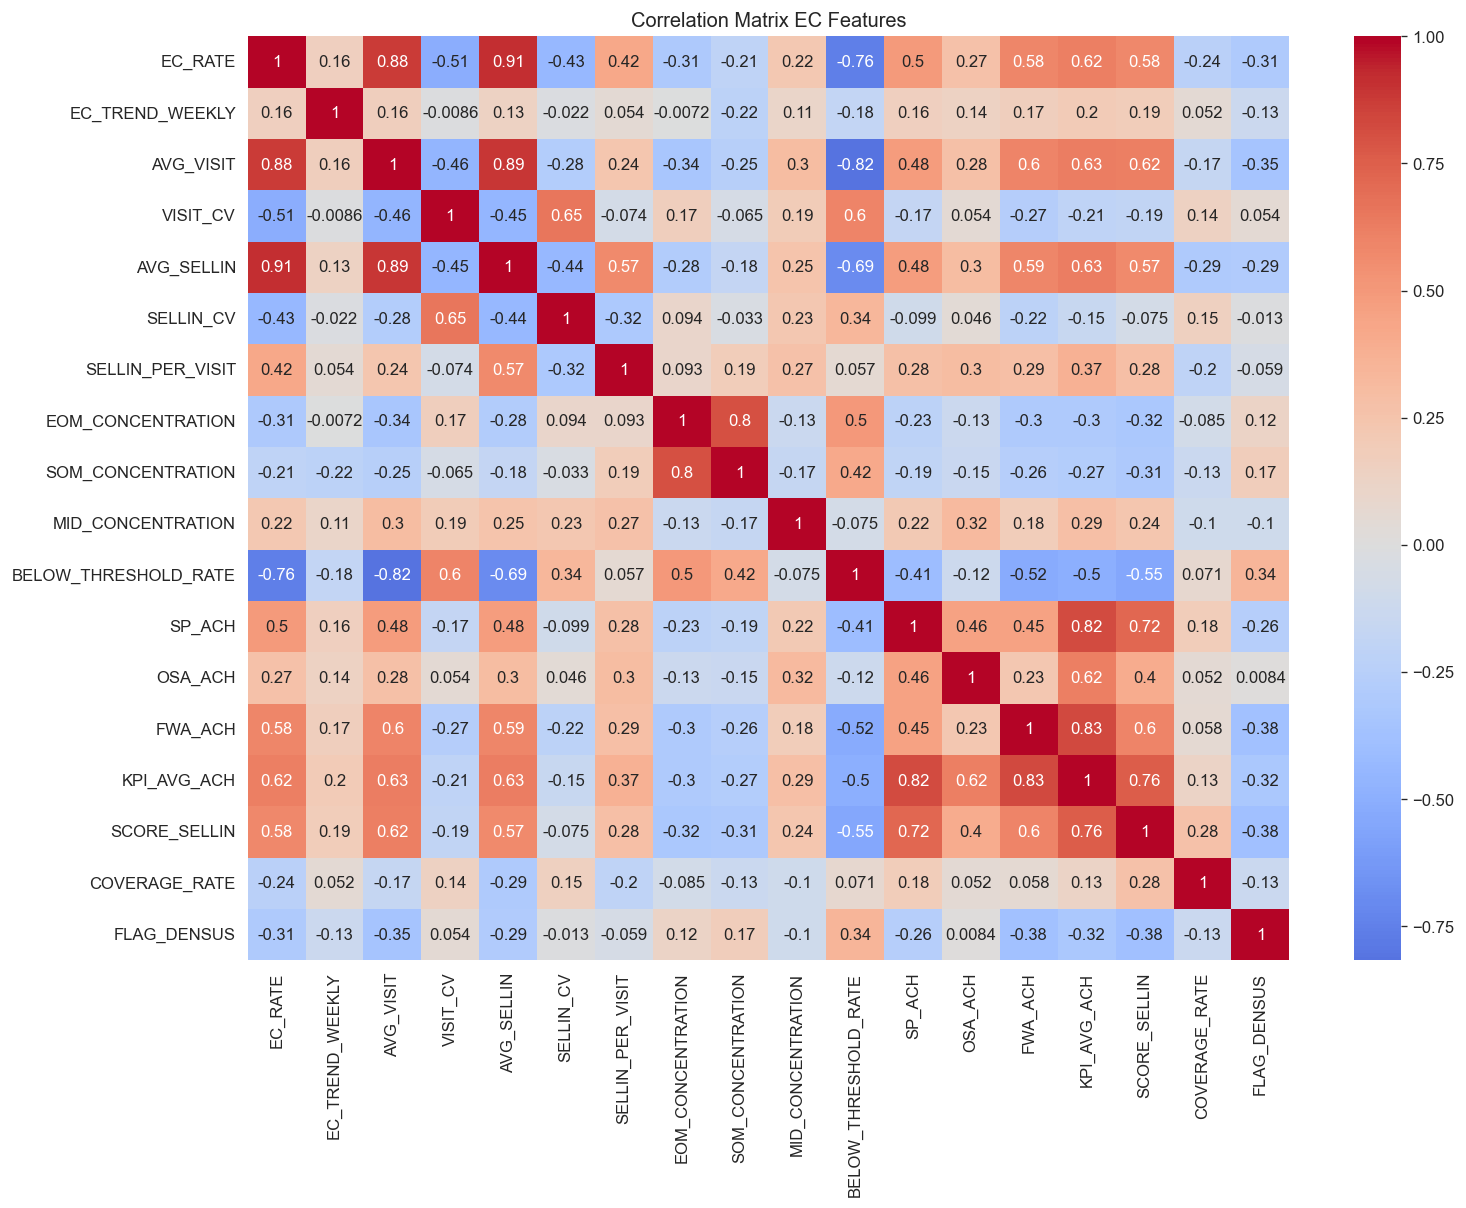

In [81]:
corr = df_feat[MODEL_FEATURES].corr(numeric_only=True)

plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix EC Features")
plt.show()

---
## **5. Anomaly Detection** — Isolation Forest

In [82]:
X = df_feat[MODEL_FEATURES].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(
    n_estimators=300,
    contamination=0.10,
    max_features=0.8,
    random_state=42
)
iso.fit(X_scaled)

df_feat['ANOMALY_SCORE_RAW'] = iso.score_samples(X_scaled)
df_feat['IS_ANOMALY']        = iso.predict(X_scaled)

s = df_feat['ANOMALY_SCORE_RAW']
df_feat['ANOMALY_SCORE'] = ((s.max() - s) / (s.max() - s.min()) * 100).round(1)

n_anom = (df_feat['IS_ANOMALY'] == -1).sum()
print(f'DSE anomali: {n_anom} dari {len(df_feat)} ({n_anom/len(df_feat)*100:.1f}%)')

DSE anomali: 213 dari 2129 (10.0%)


In [83]:
df_feat[MODEL_FEATURES + ['ANOMALY_SCORE', 'IS_ANOMALY']].head(20)

,EC_RATE,EC_TREND_WEEKLY,AVG_VISIT,VISIT_CV,AVG_SELLIN,SELLIN_CV,SELLIN_PER_VISIT,EOM_CONCENTRATION,SOM_CONCENTRATION,MID_CONCENTRATION,BELOW_THRESHOLD_RATE,SP_ACH,OSA_ACH,FWA_ACH,KPI_AVG_ACH,SCORE_SELLIN,COVERAGE_RATE,FLAG_DENSUS,ANOMALY_SCORE,IS_ANOMALY
0,0.71,18.33,19.14,0.40,18.62,0.41,0.97,0.27,0.12,0.74,0.14,120.00,56.84,120.00,98.95,1.00,0.04,0,28.60,1
1,0.71,26.67,17.24,0.40,17.10,0.40,0.99,0.28,0.15,0.69,0.14,120.00,120.00,120.00,120.00,1.00,0.04,0,14.40,1
2,0.91,13.33,20.48,0.35,18.29,0.39,0.89,0.24,0.16,0.70,0.10,120.00,87.64,120.00,109.21,1.00,0.04,0,11.10,1
3,0.43,3.33,14.90,0.36,14.62,0.36,0.98,0.24,0.20,0.66,0.10,120.00,114.68,100.00,111.56,1.00,0.04,0,11.90,1
4,0.72,33.33,18.11,0.20,14.67,0.45,0.81,0.26,0.32,0.74,0.00,120.00,63.18,120.00,101.06,1.00,0.07,0,31.80,1
5,0.72,33.33,14.22,0.42,14.06,0.42,0.99,0.33,0.26,0.74,0.22,120.00,120.00,120.00,120.00,1.00,0.07,0,28.10,1
6,0.54,-12.38,15.83,0.39,6.00,0.60,0.38,0.18,0.15,0.62,0.12,120.00,104.65,0.00,74.88,1.00,0.07,0,35.70,1
7,0.95,6.67,13.81,0.32,13.19,0.35,0.96,0.22,0.20,0.67,0.00,120.00,107.97,120.00,115.99,1.00,0.04,0,3.60,1
8,0.36,-12.38,8.88,0.75,8.56,0.77,0.96,0.20,0.15,0.63,0.20,93.15,96.45,120.00,103.20,1.00,0.03,0,31.10,1
9,0.95,-8.33,15.48,0.40,11.43,0.62,0.74,0.23,0.20,0.69,0.00,120.00,103.41,120.00,114.47,1.00,0.04,0,11.40,1


---
## 6.  **Evaluation Model Anomaly Detection** — Isolation Forest

In [84]:
df_feat[df_feat['IS_ANOMALY']==-1][MODEL_FEATURES].describe()

,EC_RATE,EC_TREND_WEEKLY,AVG_VISIT,VISIT_CV,AVG_SELLIN,SELLIN_CV,SELLIN_PER_VISIT,EOM_CONCENTRATION,SOM_CONCENTRATION,MID_CONCENTRATION,BELOW_THRESHOLD_RATE,SP_ACH,OSA_ACH,FWA_ACH,KPI_AVG_ACH,SCORE_SELLIN,COVERAGE_RATE,FLAG_DENSUS
count,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00
mean,0.03,0.99,3.66,0.41,1.66,0.49,0.50,0.54,0.50,0.39,0.57,41.41,61.73,25.45,42.86,0.36,0.40,0.23
std,0.10,9.92,4.16,0.44,1.84,0.55,0.42,0.41,0.42,0.36,0.43,48.09,45.46,46.91,35.71,0.41,0.51,0.42
min,0.00,-50.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.15,0.06,0.00,0.00,0.00,16.76,0.00,9.04,0.00,0.00,0.00
50%,0.00,0.00,2.15,0.35,1.20,0.35,0.47,0.53,0.40,0.40,0.75,14.00,57.59,0.00,40.65,0.15,0.10,0.00
75%,0.00,0.00,4.80,0.70,2.26,0.81,1.00,1.00,1.00,0.69,1.00,91.94,110.08,0.00,70.22,0.86,0.69,0.00
max,0.68,100.00,19.57,1.57,11.58,2.83,1.00,1.00,1.00,1.00,1.00,120.00,120.00,120.00,120.00,1.00,1.96,1.00


In [85]:
df_feat[df_feat['IS_ANOMALY']==1][MODEL_FEATURES].describe()

,EC_RATE,EC_TREND_WEEKLY,AVG_VISIT,VISIT_CV,AVG_SELLIN,SELLIN_CV,SELLIN_PER_VISIT,EOM_CONCENTRATION,SOM_CONCENTRATION,MID_CONCENTRATION,BELOW_THRESHOLD_RATE,SP_ACH,OSA_ACH,FWA_ACH,KPI_AVG_ACH,SCORE_SELLIN,COVERAGE_RATE,FLAG_DENSUS
count,"1,916.00","1,916.00","1,916.00","1,916.00","1,916.00","1,916.00","1,916.00","1,916.00","1,916.00","1,916.00","1,916.00","1,916.00","1,916.00","1,916.00","1,916.00","1,916.00","1,916.00","1,916.00"
mean,0.55,5.77,13.60,0.39,10.63,0.46,0.77,0.26,0.21,0.62,0.23,96.61,103.48,91.67,97.25,0.90,0.53,0.07
std,0.38,10.55,6.08,0.20,6.26,0.23,0.22,0.08,0.08,0.08,0.31,33.39,21.17,48.24,24.63,0.25,0.64,0.25
min,0.00,-33.33,1.12,0.06,0.67,0.06,0.05,0.06,0.03,0.31,0.00,0.00,11.69,0.00,7.04,0.00,0.00,0.00
25%,0.14,0.00,9.76,0.25,4.84,0.30,0.62,0.22,0.16,0.58,0.00,92.28,94.74,100.00,80.00,1.00,0.04,0.00
50%,0.64,0.00,14.86,0.35,10.24,0.42,0.82,0.24,0.21,0.62,0.09,110.00,110.16,120.00,108.33,1.00,0.06,0.00
75%,0.91,13.33,17.86,0.50,15.90,0.58,0.97,0.28,0.24,0.66,0.32,120.00,120.00,120.00,114.87,1.00,1.14,0.00
max,1.00,33.33,29.67,1.65,28.33,1.76,1.00,0.80,0.88,0.98,1.00,120.00,120.00,120.00,120.00,1.00,2.00,1.00


In [86]:
df_feat['IS_ANOMALY'].value_counts(normalize=True)

IS_ANOMALY
 1   0.90
-1   0.10
Name: proportion, dtype: float64

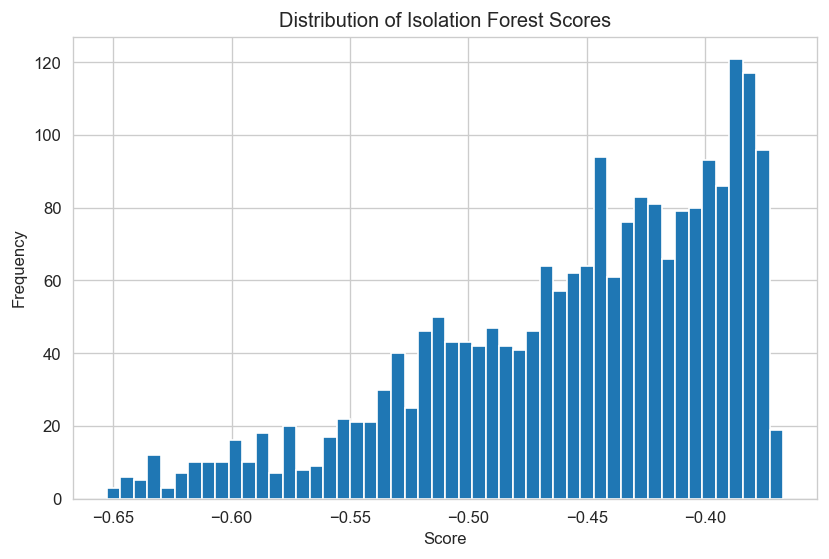

In [87]:

plt.figure(figsize=(8,5))
plt.hist(df_feat['ANOMALY_SCORE_RAW'], bins=50)
plt.title("Distribution of Isolation Forest Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

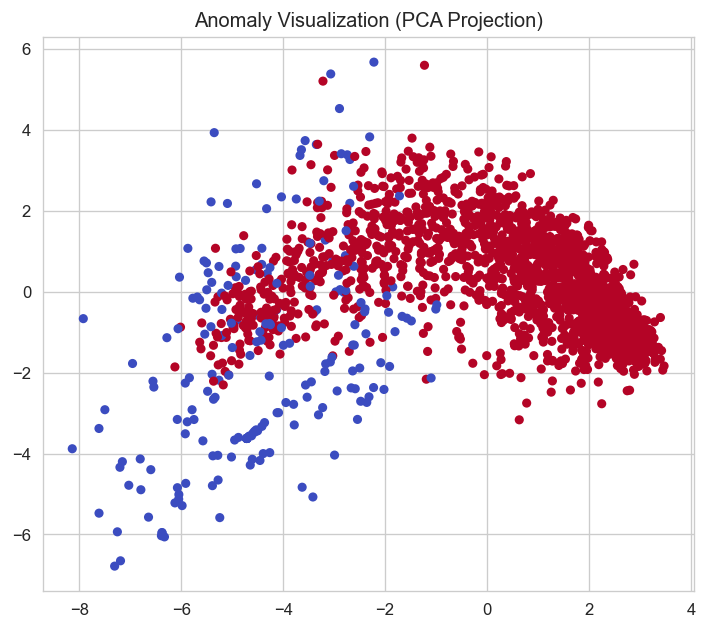

In [88]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df_feat['IS_ANOMALY'],
    cmap='coolwarm',
    s=20
)
plt.title("Anomaly Visualization (PCA Projection)")
plt.show()

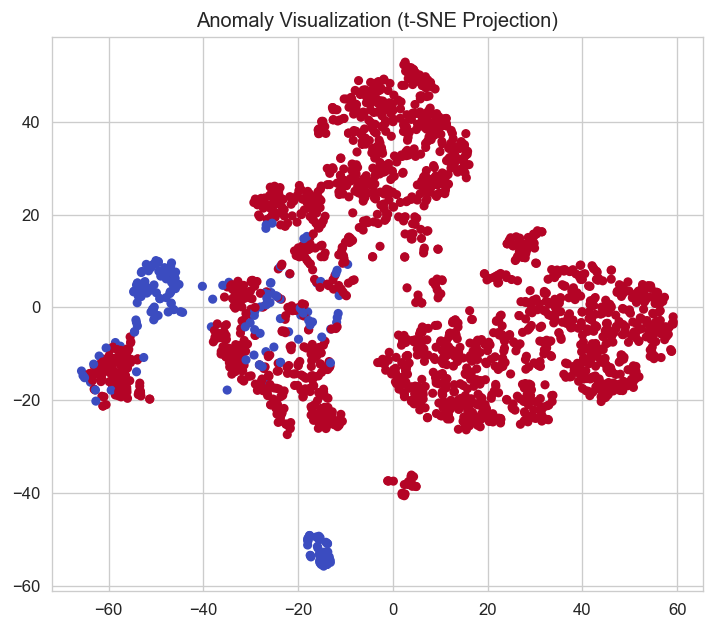

In [89]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Plot menggunakan kode scatter yang sama dengan X_tsne
plt.figure(figsize=(7,6))
plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=df_feat['IS_ANOMALY'],
    cmap='coolwarm',
    s=20
)
plt.title("Anomaly Visualization (t-SNE Projection)")
plt.show()

In [90]:
mask = df_feat['IS_ANOMALY'].isin([1, -1])

sil_score = silhouette_score(
    X_scaled[mask],
    df_feat.loc[mask, 'IS_ANOMALY']
)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.4182230889673762


In [91]:
# pseudo label (contoh rule)
y_true = (
    (df_feat['EC_RATE'] < 0.2) |
    (df_feat['BELOW_THRESHOLD_RATE'] > 0.8)
).astype(int)

# score (semakin kecil semakin anomalous → dibalik)
y_score = -df_feat['ANOMALY_SCORE_RAW']

roc = roc_auc_score(y_true, y_score)

print("ROC-AUC:", roc)

ROC-AUC: 0.9412357227428827


In [92]:

iso2 = IsolationForest(
    n_estimators=300,
    contamination=0.10,
    random_state=99
)

iso2.fit(X_scaled)

df_feat['IS_ANOMALY_2'] = iso2.predict(X_scaled)

stability = (df_feat['IS_ANOMALY'] == df_feat['IS_ANOMALY_2']).mean()

print("Stability Score:", stability)

Stability Score: 0.9859088774072334


In [93]:
df_feat.drop(columns=['IS_ANOMALY_2'], inplace=True)
df_feat['RANK'] = df_feat['ANOMALY_SCORE'].rank(ascending=False)

df_feat.sort_values('RANK').head(10)

,DSE_ID,BRAND_SRC,OUTLET,THRESHOLD_EC,N_HARI_KERJA,AVG_VISIT,VISIT_CV,AVG_SELLIN,SELLIN_CV,SELLIN_PER_VISIT,EC_RATE,EC_TREND_WEEKLY,EOM_CONCENTRATION,SOM_CONCENTRATION,MID_CONCENTRATION,BELOW_THRESHOLD_RATE,TOTAL_SELLIN_SUMMARY,TOTAL_VISIT_SUMMARY,AVG_EC_SUMMARY,FLAG_DENSUS,PARTNER_NAME,MICRO_CLUSTER,BRANCH,AREA,REGION,SP_TARGET,SP_ACTUAL,SP_ACH,SP_UNIT_PRICE,SP_INCENTIVE,OSA_TARGET,OSA_ACTUAL,OSA_ACH,OSA_UNIT_PRICE,OSA_INCENTIVE,FWA_TARGET,FWA_ACTUAL,FWA_ACH,FWA_UNIT_PRICE,FWA_INCENTIVE,OUTLET_MAPPING,FLAG_TARGET,TARGET_SELLIN,SP_SELLIN_ACTUAL,SCORE_SELLIN,SCORE_EC,CHAMP_TOTAL,KPI_AVG_ACH,KPI_STD,COMPLIANCE_INDEX,TOTAL_INCENTIVE,INCENTIVE_FINAL_AFTER_COMPLIANCE,COVERAGE_RATE,ANOMALY_SCORE_RAW,IS_ANOMALY,ANOMALY_SCORE,RANK
1518,2-0012350464,3ID,21,5,1,7.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,0,7,0.00,1,PT GLOBAL BIMA UTAMA,CS PRINGABAYA,LOMBOK TIMUR,BALI NUSRA,BALI NUSRA,124,9,7.26,0,0,"7,435,922.28",6648000,89.40,0.00,0.00,1,0,0.00,0,0,21,0.80,17,1.00,0.06,0.00,0.30,32.22,49.65,0.00,0.00,0.00,0.06,-0.65,-1,100.00,1.00
371,CSO-BJN-18,IM3,74,5,3,16.00,0.50,5.00,0.82,0.31,0.33,0.00,1.00,1.00,0.00,0.00,15,48,15.00,0,"SAKALAGUNA SEMESTA, PT",MC-BOJONEGORO,TUBAN LAMONGAN,WESTERN EAST JAVA,EAST JAVA,250,0,0.00,0,0,"106,778,614.10",5205000,4.87,0.00,0.00,1,2,120.00,200000,200000,74,0.50,37,0.00,0.00,0.10,0.37,41.62,67.92,0.00,"200,000.00","200,000.00",0.00,-0.65,-1,99.00,2.00
1235,2-0012326499,3ID,61,8,1,3.00,0.00,3.00,0.00,1.00,0.00,0.00,1.00,1.00,0.00,1.00,3,3,3.00,1,PT MITRA DISTRIBUSI MANDIRI,CS TRENGGALEK,TULUNGAGUNG,EASTERN EAST JAVA,EAST JAVA,103,172,120.00,1500,0,"102,100,154.30",51637250,50.58,0.00,0.00,1,0,0.00,0,0,61,0.50,31,36.00,1.00,0.00,0.63,56.86,60.25,0.00,0.00,0.00,1.16,-0.65,-1,98.40,3.00
1002,DSEPRINGGABAYA2,IM3,19,8,6,5.83,0.55,0.17,2.24,0.03,0.00,0.00,0.94,0.91,0.40,0.50,1,35,0.00,1,"GLOBAL BIMA UTAMA, PT",MC-PRINGABAYA,LOMBOK TIMUR,BALI NUSRA,BALI NUSRA,82,144,120.00,1500,0,"1,172,595.62",4335000,120.00,0.00,0.00,1,0,0.00,0,0,19,0.80,15,1.20,0.07,0.00,0.84,80.00,69.28,0.00,0.00,0.00,0.08,-0.65,-1,97.50,4.00
1733,1-158560006153,3ID,36,8,6,4.33,0.58,0.67,2.24,0.15,0.00,0.00,0.65,0.92,0.23,0.83,4,26,4.00,0,PT MITRA DISTRIBUSI MANDIRI,CS PATI,PATI,NORTH CENTRAL JAVA,CENTRAL JAVA,2224,0,0.00,0,0,"111,950,739.30",594000,0.53,0.00,0.00,1,0,0.00,0,0,36,0.50,18,0.00,0.00,0.00,0.00,0.18,0.31,0.00,0.00,0.00,0.00,-0.64,-1,97.20,5.00
1906,1-194893383639,3ID,40,5,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0.00,1,PT TELEFAST INDONESIA,CS BOYOLALI SELATAN,KLATEN,SOUTH CENTRAL JAVA,CENTRAL JAVA,292,421,120.00,1500,0,"40,782,662.92",25692500,63.00,0.00,0.00,1,1,100.00,100000,0,40,0.50,20,30.00,1.00,0.00,0.97,94.33,28.92,0.00,0.00,0.00,1.50,-0.64,-1,97.00,6.00
2079,1-194900309249,3ID,39,8,1,9.00,0.00,9.00,0.00,1.00,0.00,0.00,1.00,1.00,1.00,0.00,9,9,0.00,0,CV NUSANTARA MAKMUR PERKASA,CS CILACAP SELATAN,PURWOKERTO,SOUTH CENTRAL JAVA,CENTRAL JAVA,810,155,19.14,0,0,"168,009,836.70",6300027,3.75,0.00,0.00,1,0,0.00,0,0,39,0.50,20,9.00,0.45,0.00,0.09,7.63,10.14,0.00,0.00,0.00,0.45,-0.64,-1,96.80,7.00
1938,1-175328031119,3ID,13,8,3,11.67,0.11,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,0,35,0.00,0,KIOSK_WIDIYANTORO_SALEM_BREBES,CS BREBES SELATAN,TEGAL,NORTH CENTRAL JAVA,CENTRAL JAVA,246,0,0.00,0,0,"1,950,739.35",6500,0.33,0.00,0.00,1,0,0.00,0,0,13,0.50,7,0.00,0.00,0.00,0.00,0.11,0.19,0.00,0.00,0.00,0.00,-0.64,-1,96.10,8.00
1025,DSEPRAYA3,IM3,18,8,5,7.00,0.38,1.60,0.75,0.23,0.00,0.00,1.00,1.00,0.29,0.40,8,35,100.00,1,"GLOBAL BIMA UTAMA, PT",MC-PRAYA,LOMBOK TIMUR,BALI NUSRA,BALI NUSRA,56,0,0.00,0,0,"9,204,639.20",1936000,21.03,0.00,0.00,1,0,0.00,0,0,18,0.80,14,0.00,0.00,0.00,0.06,7.01,12.14,0.00,0.00,0.00,0.00,-0.64,-1,96.00,9.00
1905,1-28825219427,3ID,39,5,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0,0.00,1,PT TELEFAST INDONESIA,CS BOYOLALI SELATAN,KLATEN,SOUTH CENTRAL JAVA,CENTRAL JAVA,292,301,103.08,1500,0,"28,100,302.66",15916500,56.64,0.00,0.00,1,1,100.00,100000,0,39,0.50,20,25.00,1.00,

---
## 7.  **Clustering** — K-Means

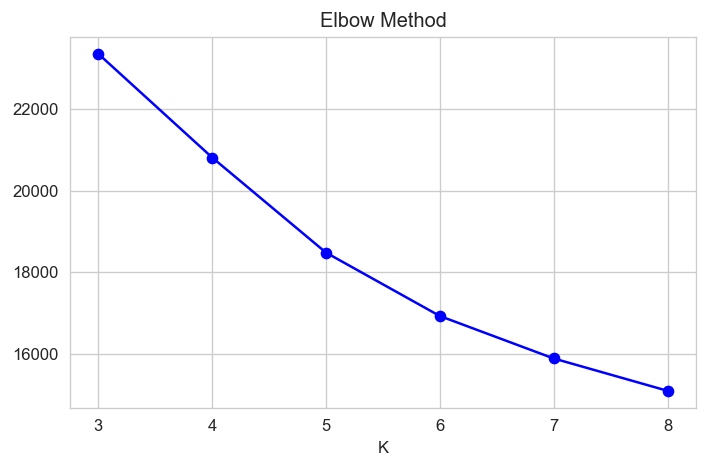

Optimal K: 5


In [94]:
inertias = []
K_range = range(3, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_range, inertias, 'bo-')
plt.title('Elbow Method')
plt.xlabel('K')
plt.tight_layout()
plt.show()

best_k = 5
print(f'Optimal K: {best_k}')

In [95]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_feat['CLUSTER'] = km_final.fit_predict(X_scaled)

# ── Profiling tiap cluster
cluster_profile = df_feat.groupby('CLUSTER')[
    MODEL_FEATURES + ['ANOMALY_SCORE', 'IS_ANOMALY']
].mean().round(2)

print(cluster_profile.T)

CLUSTER                  0     1      2      3     4
EC_RATE               0.01  0.04   0.41   0.87  0.00
EC_TREND_WEEKLY       0.88  1.00   7.65   6.24  0.00
AVG_VISIT             3.24  4.94  12.24  18.37  0.29
VISIT_CV              0.30  0.65   0.43   0.27  0.00
AVG_SELLIN            2.01  2.57   7.63  16.35  0.00
SELLIN_CV             0.37  0.68   0.54   0.33  0.00
SELLIN_PER_VISIT      0.80  0.66   0.65   0.89  0.00
EOM_CONCENTRATION     0.98  0.34   0.23   0.25  0.01
SOM_CONCENTRATION     0.97  0.26   0.17   0.22  0.01
MID_CONCENTRATION     0.37  0.62   0.60   0.63  0.01
BELOW_THRESHOLD_RATE  0.84  0.71   0.22   0.03  0.00
SP_ACH               53.10 53.72 102.83 107.26 30.77
OSA_ACH              69.25 93.03 102.45 106.80 30.66
FWA_ACH              27.06 22.67  98.05 114.99 17.60
KPI_AVG_ACH          49.80 56.47 101.11 109.68 26.35
SCORE_SELLIN          0.41  0.47   0.98   1.00  0.26
COVERAGE_RATE         0.49  0.36   1.18   0.07  0.29
FLAG_DENSUS           0.25  0.28   0.01   0.02

In [96]:
# ── Beri nama label cluster berdasarkan profil
# Setelah lihat cluster_profile.T, isi mapping ini manual:

CLUSTER_LABEL_MAP = {
    0: 'High Risk - Low Performance',       
    1: 'Medium Risk - Underperformer',  
    2: 'Low Risk - Healthy Performer',
    3: 'Low Risk - Top Performer',   
    4: 'Critical Risk - Inactive',        
}

df_feat['CLUSTER_LABEL'] = df_feat['CLUSTER'].map(CLUSTER_LABEL_MAP)

# Distribusi
print(df_feat['CLUSTER_LABEL'].value_counts())

CLUSTER_LABEL
Low Risk - Top Performer        859
Low Risk - Healthy Performer    708
Medium Risk - Underperformer    427
High Risk - Low Performance      85
Critical Risk - Inactive         50
Name: count, dtype: int64


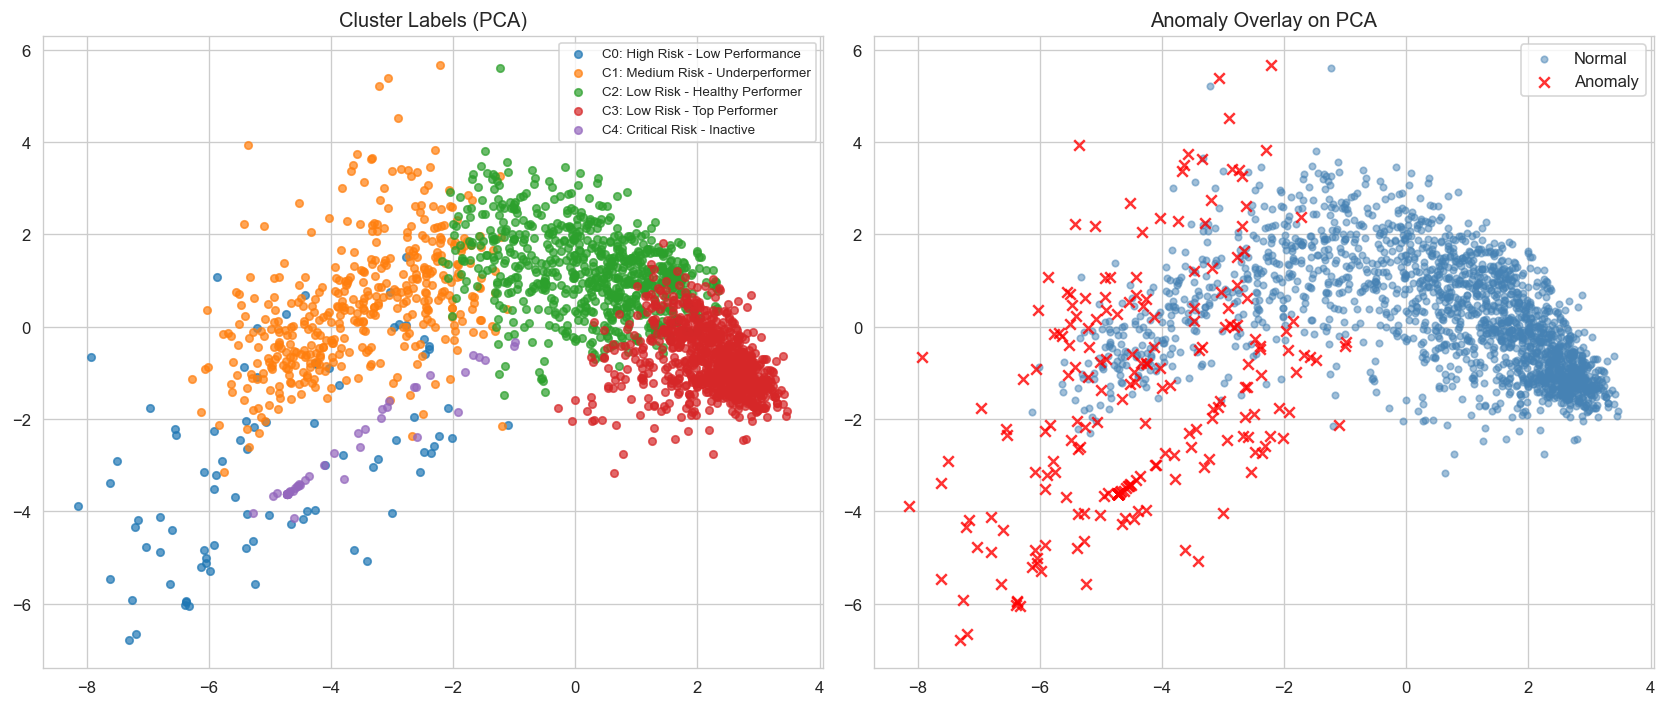

In [97]:
# ── Visualisasi cluster di PCA space, overlay anomaly
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mapping label & warna per cluster
CLUSTER_LABEL_MAP = {
    0: 'High Risk - Low Performance',       
    1: 'Medium Risk - Underperformer',  
    2: 'Low Risk - Healthy Performer',
    3: 'Low Risk - Top Performer',   
    4: 'Critical Risk - Inactive',        
}

tab10 = plt.cm.tab10
colors = {k: tab10(k / 10) for k in CLUSTER_LABEL_MAP}

# Plot 1: Warna per cluster + legend label
for cluster_id, label in CLUSTER_LABEL_MAP.items():
    mask = df_feat['CLUSTER'] == cluster_id
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=[colors[cluster_id]],
        label=f'C{cluster_id}: {label}',
        s=20, alpha=0.7
    )
axes[0].legend(fontsize=8, loc='best')
axes[0].set_title('Cluster Labels (PCA)')

# Plot 2: Overlay anomaly di atas cluster
normal  = df_feat['IS_ANOMALY'] == 1
anomaly = df_feat['IS_ANOMALY'] == -1
axes[1].scatter(X_pca[normal,  0], X_pca[normal,  1], c='steelblue', s=15, alpha=0.5, label='Normal')
axes[1].scatter(X_pca[anomaly, 0], X_pca[anomaly, 1], c='red',       s=40, alpha=0.8, label='Anomaly', marker='x')
axes[1].legend()
axes[1].set_title('Anomaly Overlay on PCA')

plt.tight_layout()
plt.show()

# INTERPRETASI

In [98]:
def generate_reason(row):

    reasons = []

    if row['N_HARI_KERJA'] < 10:
        reasons.append("Hari kerja/aktif relatif rendah")

    if row['EC_RATE'] < 0.3:
        reasons.append("EC rendah")

    if row['KPI_AVG_ACH'] < 50:
        reasons.append("KPI rendah")

    if row['BELOW_THRESHOLD_RATE'] > 0.7:
        reasons.append("Sering di bawah threshold")

    if row['SELLIN_PER_VISIT'] < 10000:
        reasons.append("Sellin per visit rendah")

    if row['EOM_CONCENTRATION'] > 0.4:
        reasons.append("Aktivitas menumpuk akhir bulan")

    if not reasons:
        reasons.append("Pola aktivitas berbeda dari mayoritas DSE")

    return ", ".join(reasons)

df_feat['ANOMALY_REASON'] = df_feat.apply(generate_reason, axis=1)

In [99]:
df_feat.loc[
    df_feat['IS_ANOMALY'] == -1,
    ['DSE_ID','ANOMALY_SCORE','ANOMALY_REASON']
].sort_values(
    'ANOMALY_SCORE',
    ascending=False
).head(20)

,DSE_ID,ANOMALY_SCORE,ANOMALY_REASON
1518,2-0012350464,100.00,"Hari kerja/aktif relatif rendah, EC rendah, KP..."
371,CSO-BJN-18,99.00,"Hari kerja/aktif relatif rendah, KPI rendah, S..."
1235,2-0012326499,98.40,"Hari kerja/aktif relatif rendah, EC rendah, Se..."
1002,DSEPRINGGABAYA2,97.50,"Hari kerja/aktif relatif rendah, EC rendah, Se..."
1733,1-158560006153,97.20,"Hari kerja/aktif relatif rendah, EC rendah, KP..."
1906,1-194893383639,97.00,"Hari kerja/aktif relatif rendah, EC rendah, Se..."
2079,1-194900309249,96.80,"Hari kerja/aktif relatif rendah, EC rendah, KP..."
1938,1-175328031119,96.10,"Hari kerja/aktif relatif rendah, EC rendah, KP..."
1025,DSEPRAYA3,96.00,"Hari kerja/aktif relatif rendah, EC rendah, KP..."
1905,1-28825219427,95.50,"Hari kerja/aktif relatif rendah, EC rendah, Se..."


In [100]:
import joblib

In [101]:
joblib.dump(
    iso,
    "../models/isolation_forest.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

joblib.dump(
    MODEL_FEATURES,
    "../models/features.pkl"
)

['../models/features.pkl']

In [102]:
import os
print(os.listdir("../models"))

['features.pkl', 'isolation_forest.pkl', 'scaler.pkl']


---
## 📋 Ringkasan Fitur & Interpretasi

### Fitur dari Sheet EC (Harian)
| Feature | Deskripsi |
|----------|----------|
| EC_RATE | Persentase hari dengan EC = 100 |
| EC_TREND_WEEKLY | Tren EC antar minggu (positif=membaik, negatif=memburuk) |
| AVG_VISIT | Rata-rata jumlah kunjungan |
| VISIT_CV | Koefisiensi variasi visit (konsistensi kunjungan; makin kecil = makin stabil) |
| AVG_SELLIN | Rata-rata transaksi sell in per hari kerja |
| SELLIN_CV | Variasi sell in (konsistensi penjualan harian) |
| SELLIN_PER_VISIT | Efektivitas kunjungan menghasilkan sell in |
| EOM_CONCENTRATION | Proporsi visit di 5 hari terakhir bulan (End of Month behavior)|
| SOM_CONCENTRATION | Proporsi visit di 5 hari pertama bulan (Start of Month behavior) |
| MID_CONCENTRATION | Proporsi visit di hari tengah bulan (hari 8–22) |
| BELOW_THRESHOLD_RATE | Proporsi hari di mana visit/sell-in di bawah threshold EC |

### Fitur dari Sheet Utama (KPI)

| Fitur | Keterangan |
|----------|----------|
| SP_ACH | Presentase achievement SP |
| OSA_ACH | Presentase achievement OSA |
| FWA_ACH | Presentase achievement FWA |
| KPI_AVG_ACH | Rata-rata achievement KPI |
| SCORE_SELLIN | Skor performa sell in |
| COVERAGE_RATE | Rasio SP actual terhadap target sell-in (SP SELLIN actual / TARGET SELLIN) |
| FLAG_DENSUS | Indikator Densus |
| ANOMALY_SCORE | Tingkat penyimpangan dari mayoritas DSE |
| ANOMALY_RATE | Persentase DSE anomali dalam cluster |